In [1]:
%load_ext autoreload
%autoreload 2
cmd = "S"
import sys
parent_dir = "C:/Users/yuhang.hou/projects/holidays/poc_backtester/data_pipeline/universal"

import json
import pandas as pd
import os
import pickle
sys.path.append(parent_dir)
holidays_path = "C:/Users/yuhang.hou/projects/holidays"
sys.path.append(holidays_path)
from backtester import *
from utils import *

last_trading_days = get_last_trading_days(cmd)
ltds = {k:pd.to_datetime(v) for k,v in last_trading_days.items()}

business_days = load_business_days_cmd(cmd)
business_days = sorted(business_days)

def process_results(results):
    res =[]
    for date, data in results.items():
        temp= { }
        temp['date'] = date
        temp['level'] = data['level']
        temp['tc'] = data['tc']
        res.append(temp)
    res = pd.DataFrame(res)
    res = res.set_index('date')
    res['tc_cumsum'] = res['tc'].cumsum()
    return res

def load_future_data(data_path = f'./data/{cmd}',values = 'close'):
    files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
    dfs = (pd.read_csv(os.path.join(data_path, file)).assign(
        contract=file.replace('.csv', ''),
        date=lambda df: pd.to_datetime(df['date'])
    ) for file in files)

    big_df = pd.concat(dfs, ignore_index=True)
    pivot_df = big_df.pivot(index='date', columns='contract', values= values)

    return pivot_df

contract_df = load_future_data(f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/future/cme/{cmd}',['close'])
contract_df = contract_df.ffill()
# contract_df.head()
contract_df.dropna(how='all', inplace=True)
contract_df = contract_df[contract_df.index.isin(business_days)]
start_date = '2004-01-02'
end_date = '2026-02-10'

In [2]:
final_df = pd.DataFrame()

<Axes: xlabel='date'>

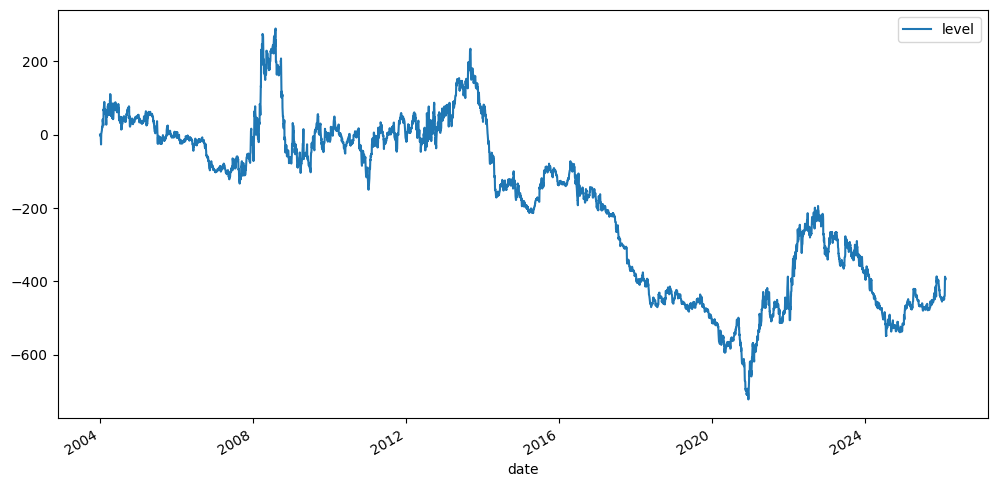

In [19]:
import numpy as np

from poc_backtester.data_pipeline.universal.backtester import WeightBacktester

config = {
    'start_date': start_date,
    'end_date': end_date,
    'max_position': 1,
    'cost_type':'percentage',
    'slippage': 0.0,
    'commission': 0,
    'roll_out' : 1,
    'vol_target': 5000,
    'round': 0,
    'max_daily_volume': 1,
    'lookback':10,
    'symbol': cmd,
    'weight_path':f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data_pipeline/universal/{cmd}_weights.csv'

}

backtest = WeightBacktester(
    data = contract_df,
    config = config,
    trading_days=business_days,
    last_trading_day=ltds
)
                
results = backtest.run_backtest()
res = process_results(results)
final_df['level'] = res['level']  
final_df.plot(figsize=(12,6))




In [97]:
signals = pd.read_csv(f'C:\\Users\\yuhang.hou\\projects\\holidays\\poc_backtester\\data_pipeline\\universal\\{cmd}_final.csv')
signals['date'] = pd.to_datetime(signals['date'])
signals = signals.set_index('date')
signals['level'] = final_df['level']
signals['level_diff'] = signals['level'].diff(10).shift(11)
signals.dropna(inplace=True)
print(signals.corr())
# signals['level_diff'] = signals['level_diff'].apply(lambda x: 1 if x>0 else (-1 if x<0 else 0))
# signals.head(20)

                   0     level  level_diff
0           1.000000 -0.296449    0.010926
level      -0.296449  1.000000    0.016935
level_diff  0.010926  0.016935    1.000000


<Axes: xlabel='0', ylabel='level_diff'>

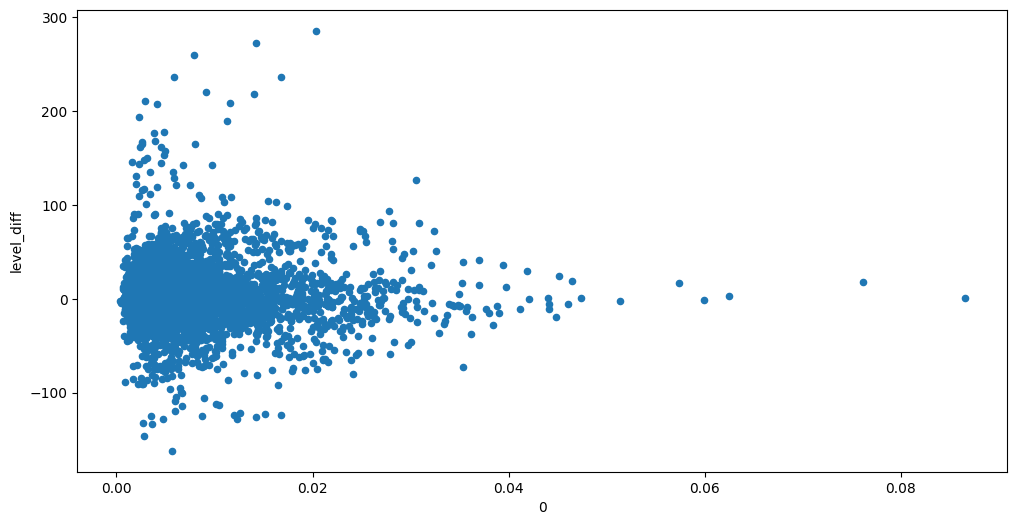

In [98]:
signals.plot.scatter(x='0', y='level_diff', figsize=(12,6))